# Visualize cameras

### Import libraries

In [8]:
import open3d as o3d
import pycolmap
import numpy as np

In [ ]:
# Define your paths
paths = [
    
    "/media/leonardo/Leo_HD/data/TUM_RGBD_EPO/fr1_desk/final_data/mapping/1",      # GT (red)
    "/media/leonardo/Leo_HD/data/TUM_RGBD_EPO/fr1_desk/final_data/mapping/noisy_1",      # GT (Green)
    "optimized_reconstruction_GD/seq_1",  # opt results (blue)
    
    #"/media/leonardo/Leo_HD/data/TUM_RGBD_EPO/fr1_desk/VGGT/GT",
    #"/media/leonardo/Leo_HD/data/TUM_RGBD_EPO/fr1_desk/VGGT_old/0", # VGGT (red)
    #"/home/leonardo/Desktop/Code/EPO/optimized_reconstruction_GD/fr_desk_VGGT_K" # Blue
]

In [7]:
def compute_relative_scale(recon1, recon2):
    """Computes scale s such that recon2 = s * recon1"""
    distances1 = []
    distances2 = []
    
    # Get common image IDs to ensure we are comparing the same movement
    common_ids = set(recon1.images.keys()) & set(recon2.images.keys())
    img_ids = sorted(list(common_ids))
    
    for i in range(len(img_ids) - 1):
        id1, id2 = img_ids[i], img_ids[i+1]
        
        # Distance between camera i and i+1 in Reconstruction 1
        p1_a = recon1.images[id1].projection_center()
        p1_b = recon1.images[id2].projection_center()
        distances1.append(np.linalg.norm(p1_a - p1_b))
        
        # Distance between camera i and i+1 in Reconstruction 2
        p2_a = recon2.images[id1].projection_center()
        p2_b = recon2.images[id2].projection_center()
        distances2.append(np.linalg.norm(p2_a - p2_b))
    
    # Avoid division by zero
    distances1 = np.array(distances1)
    distances2 = np.array(distances2)
    mask = distances1 > 1e-6 
    
    # Scale = Median of (Dist2 / Dist1)
    scale = np.median(distances2[mask] / distances1[mask])
    return scale

In [5]:
def get_camera_frames(reconstruction, color, scale=1.0, frame_size=0.1):
    """
    Returns a list of coordinate frames representing camera positions and orientations.
    """
    frames = []
    s = scale if scale is not None else 1.0

    images = list(reconstruction.images.values())
    images = images[::5]
    
    for image in images:
        # 1. Get the Camera Center (Translation)
        center = image.projection_center() * s
        
        # 2. Get the Rotation Matrix (World to Camera)
        # Note: We need Camera to World (inverse) for visualization
        R_world_cam = image.cam_from_world.rotation.matrix().T 
        
        # 3. Create a small coordinate frame for this camera
        # Red = X, Green = Y, Blue = Z (pointing out of the camera)
        frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=frame_size)
        
        # 4. Apply rotation and then translation
        frame.rotate(R_world_cam, center=(0, 0, 0))
        frame.translate(center)
        
        # (Optional) Paint the frame a specific color 
        # Note: Painting a coordinate frame overwrites the RGB axes colors
        # frame.paint_uniform_color(color) 
        
        frames.append(frame)
        
    return frames

# Order matches the list above: [G, R, B]
colors = [
    [0, 1, 0], # GT: Green
    [1, 0, 0], # GT+noise / VGGT: Red
    [0, 0, 1]  # EPO: Blue
]

all_geos = []

for path, color in zip(paths, colors):
    try:
        recon = pycolmap.Reconstruction(path)
        # Get the frames instead of just points
        camera_frames = get_camera_frames(recon, color, scale=1.0)
        all_geos.extend(camera_frames) # Use extend for list of geometries
    except Exception as e:
        print(f"Error: {e}")

# Add a coordinate frame at the origin for spatial context
all_geos.append(o3d.geometry.TriangleMesh.create_coordinate_frame(size=0.2))

# Visualize
print("Visualizing... (Close window to stop)")
o3d.visualization.draw_geometries(all_geos, window_name="Camera Trajectory Comparison")


Error: name 'pycolmap' is not defined
Error: name 'pycolmap' is not defined
Error: name 'pycolmap' is not defined
Visualizing... (Close window to stop)


In [6]:
import open3d as o3d
import numpy as np
import os

def get_camera_points(reconstruction, def_color, scale=1.0, special_color=None):
    """
    Returns a PointCloud representing the camera centers.
    If special_color is provided, returns (main_pcd, special_pcd) tuple.
    """
    points = []
    special_points = []
    def_s = scale if scale is not None else 1.0

    # Extract camera centers
    images = list(reconstruction.images.values())
    # You can remove [::5] if you want to see every single camera point
    for image in images:
        center = image.projection_center() * def_s
        
        if image.name == '1/00568.png' or image.name == "1/00565.png" or image.name == "1/00562.png":
            print("found special point!")
            special_points.append(center)
        else:
            points.append(center)
    
    # Create the Open3D PointCloud object for regular points
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(np.array(points))
    pcd.paint_uniform_color(def_color)
    
    # Create separate point cloud for special point if found
    special_pcd = None
    if len(special_points) > 0 and special_color is not None:
        
        special_pcd = o3d.geometry.PointCloud()
        special_pcd.points = o3d.utility.Vector3dVector(np.array(special_points))
        special_pcd.paint_uniform_color(special_color)
    
    return (pcd, special_pcd) if special_pcd is not None else (pcd, None)

# ... (colors and paths definitions stay the same)

all_geos = []
output_dir = "camera_ply_output"
os.makedirs(output_dir, exist_ok=True)

colors = [
    [0, 1, 0], # GT: Green
    [1, 0, 0], # GT+noise / VGGT: Red
    [0, 0, 1]  # EPO: Blue
]

# Combine all point clouds into one
combined_pcd = o3d.geometry.PointCloud()
special_points = []  # Store special point clouds separately

colors = [
    [0, 1, 0], # GT: Green
    [1, 0, 0], # GT+noise / VGGT: Red
    [0, 0, 1]  # EPO: Blue
]

# Special color for the marked point
special_color = [0, 0, 0]  # Black

for path, color in zip(paths, colors):
    try:
        recon = pycolmap.Reconstruction(path)
        # Get point clouds (regular and special)
        camera_pcd, special_pcd = get_camera_points(recon, color, scale=1.0, special_color=special_color)
        all_geos.append(camera_pcd)
        
        # Add to combined point cloud
        combined_pcd += camera_pcd
        
        # Store special point if found
        if special_pcd is not None:
            special_points.append(special_pcd)
            all_geos.append(special_pcd)
    except Exception as e:
        print(f"Error: {e}")

# Add origin for context
all_geos.append(o3d.geometry.TriangleMesh.create_coordinate_frame(size=0.2))

# Save combined point cloud as single PLY file
ply_path = os.path.join(output_dir, "camera_points_combined.ply")
o3d.io.write_point_cloud(ply_path, combined_pcd)
print(f"Saved combined geometry: {ply_path}")

# Visualize
o3d.visualization.draw_geometries(all_geos, window_name="Camera Trajectory Comparison")

Error: name 'pycolmap' is not defined
Error: name 'pycolmap' is not defined
Error: name 'pycolmap' is not defined
[Open3D WARNING] Write PLY failed: point cloud has 0 points.
Saved combined geometry: camera_ply_output/camera_points_combined.ply


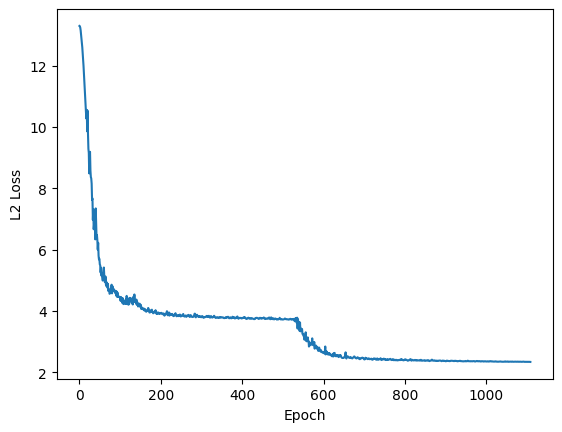

In [6]:
import json
import os
import matplotlib.pyplot as plt
benchmark_path  = "./benchmarks/vggt_edge_canny/TUM_RGBD/fr1_desk/sparse"
training_logs_path = os.path.join(benchmark_path, "training_logs.json")


with open(training_logs_path, 'r') as file:
    training_logs = json.load(file)

plt.plot(training_logs["list_loss"])
plt.xlabel("Epoch")
plt.ylabel("L2 Loss")

plt.show()

{'auc': {'1': [1.1019424536206888, 0.012265971701069849, 0.012091817414162723, 0.018351480429570098, 0.04784146027202647, 0.03633375690029534, 0.06038396172545228, 0.07117846013335027, 0.06248768589635419, 0.048256955863518254, 0.04524348988993706, 0.056553718422396905, 0.07840400026736202, 0.041731405659578974, 0.03631294861012814, 0.037227349810456625, 0.03570017490527705, 0.03507812100102521, 0.0394784538327784, 0.036310576548433254, 0.04112452330887605, 0.037634798079126085, 0.03537836779469069, 0.03515629677363463], '3': [8.707901596451363, 0.5096202935486264, 0.5059440884251267, 0.64136560941011, 1.0979756410211923, 1.4948379836210604, 1.8931754828838177, 2.0754766568011207, 2.1561263408837785, 2.4347465491605105, 2.4274173830762624, 3.0435798304660113, 3.309841315126742, 3.186113557564795, 3.250781877482508, 3.1529745520153503, 3.228714116306428, 3.090152126630741, 3.1015231475596936, 3.108195223637637, 3.1017457609754575, 3.154198015746476, 3.113372901873432, 3.11022324866842],

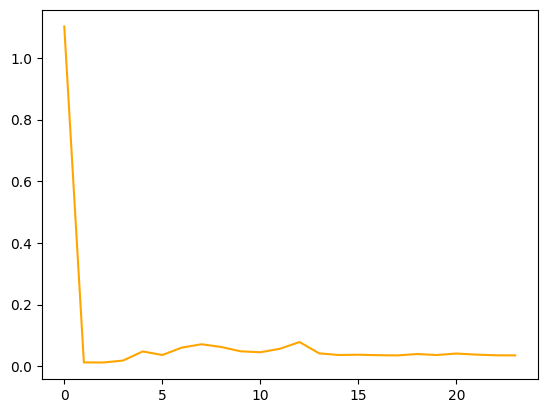

In [7]:
import json
import os
import matplotlib.pyplot as plt
benchmark_path  = "./benchmarks/vggt_edge_canny/TUM_RGBD/fr1_desk/sparse"
training_logs_path = os.path.join(benchmark_path, "training_logs.json")


with open(training_logs_path, 'r') as file:
    training_logs = json.load(file)

print(training_logs["list_auc"])
plt.plot(training_logs["list_auc"]["auc"]["1"], color= "orange")  

plt.show()

In [8]:
plt.close("all")